In [21]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")          

from src.data import ACTIVIDADES, parsear_nombre
from src.visualization import plot_espectrograma
from src.preprocessing import espectrograma

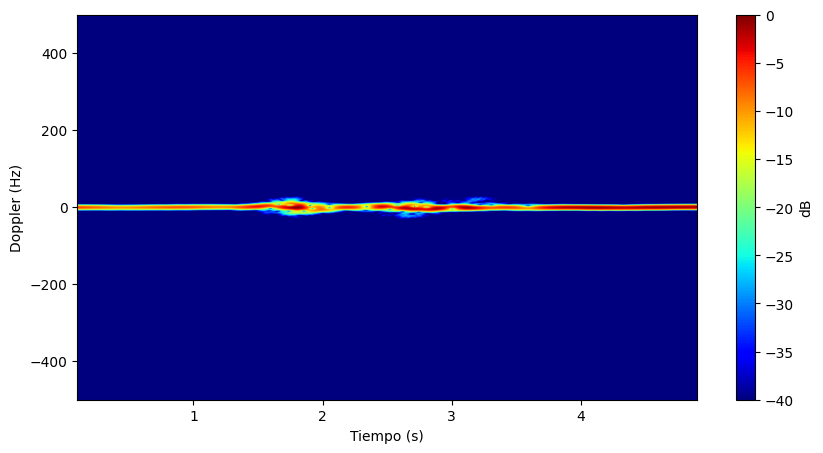

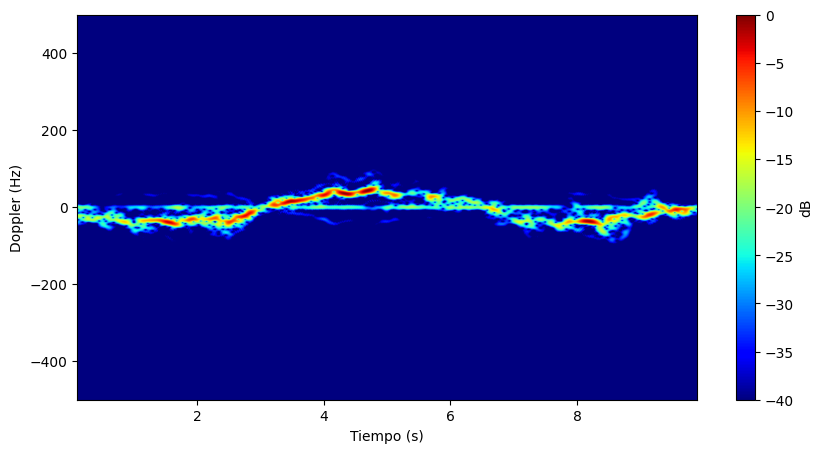

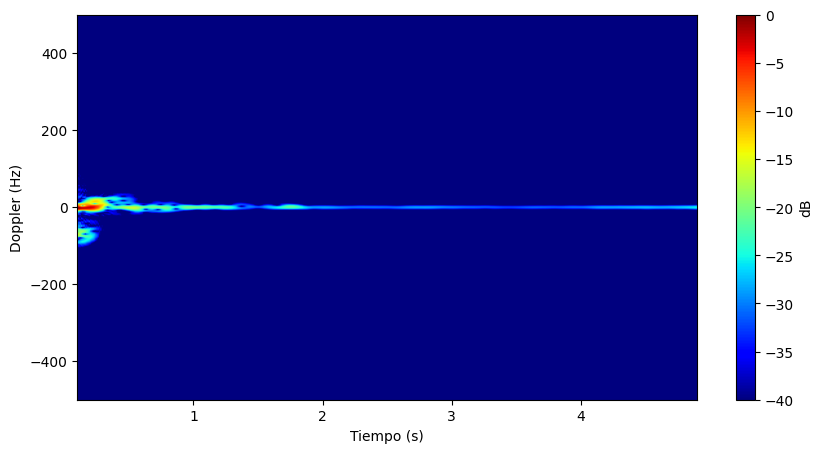

In [22]:
import numpy as np

beber = np.load("../data/processed/senales/C7_5P52A05R2.npz")
andar = np.load("../data/processed/senales/C1_1P36A01R01.npz")
caerse = np.load("../data/processed/senales/C1_6P36A06R01.npz")

senal1 = beber["senal"]
senal2 = andar["senal"]
senal3 = caerse["senal"]

t_chirp1 = beber["t_chirp"]
t_chirp2 = andar["t_chirp"]
t_chirp3 = caerse["t_chirp"]

senales = [(senal1, t_chirp1), (senal2, t_chirp2), (senal3, t_chirp3)]

for senal, t_chirp in senales:
    f, t, Z_db = espectrograma(senal, t_chirp)

    plot_espectrograma(f, t, Z_db)

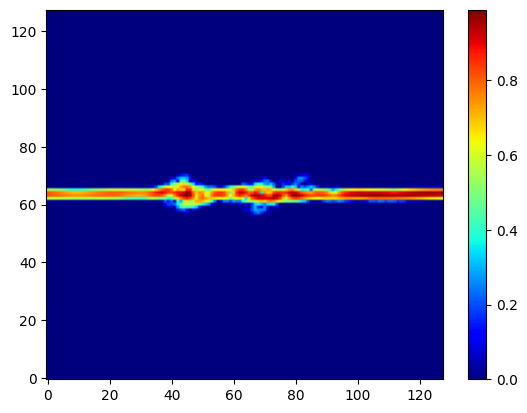

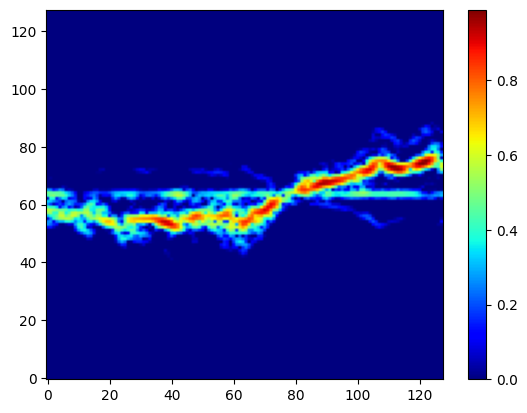

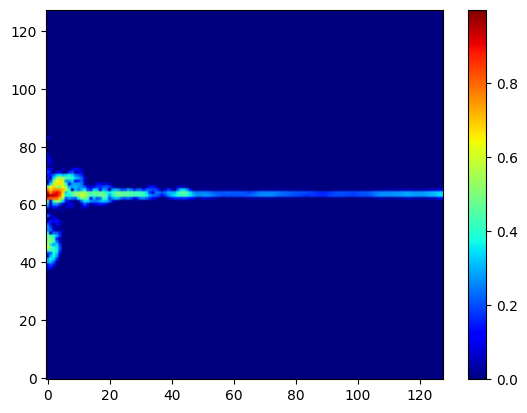

In [27]:
from src.preprocessing import preparar_espectrograma
import matplotlib.pyplot as plt

senal1 = beber["senal"]
senal2 = andar["senal"]
senal3 = caerse["senal"]

t_chirp1 = beber["t_chirp"]
t_chirp2 = andar["t_chirp"]
t_chirp3 = caerse["t_chirp"]

senales = [(senal1, t_chirp1), (senal2, t_chirp2), (senal3, t_chirp3)]

for senal, t_chirp in senales:
    imagen = preparar_espectrograma(senal, t_chirp)

    plt.figure()
    plt.imshow(imagen, origin="lower", aspect="auto", cmap="jet")
    plt.colorbar()
    plt.show()

In [30]:
import pandas as pd

df = pd.read_csv("../data/processed/metadatos.csv")

imagenes = []
ids = []

for gid in df["id"]:

    grabacion = np.load(f"../data/processed/senales/{gid}.npz")

    imagen = preparar_espectrograma(grabacion["senal"], grabacion["t_chirp"])

    imagenes.append(imagen)
    ids.append(gid)

X = np.stack(imagenes)          
ids = np.array(ids)

np.savez("../data/processed/espectrogramas_5s.npz",
         X=X, ids=ids,
         duracion_s=5, f_max=250, rango_db=40)

print(X.shape, X.min(), X.max(), len(ids))


(1754, 128, 128) 0.0 0.99985147 1754


In [31]:
df["sujeto"] = df["campana"].astype(str) + "_" + df["persona"].astype(str)

sujetos = df["sujeto"].unique()               
rng = np.random.default_rng(42)
rng.shuffle(sujetos)

n = len(sujetos)
n_test = round(n * 0.15)                       
n_valid = round(n * 0.15)

test_s  = sujetos[:n_test]
valid_s = sujetos[n_test:n_test + n_valid]
train_s = sujetos[n_test + n_valid:] 

df["particion"] = "train"
df.loc[df["sujeto"].isin(valid_s), "particion"] = "valid"
df.loc[df["sujeto"].isin(test_s),  "particion"] = "test"

print(df.groupby("particion")["sujeto"].nunique())
print(pd.crosstab(df["actividad"], df["particion"], margins=True))

df[["id", "sujeto", "particion"]].to_csv("../data/processed/particion.csv", index=False)

particion
test     16
train    74
valid    16
Name: sujeto, dtype: int64
particion  test  train  valid   All
actividad                          
1            48    218     46   312
2            48    218     46   312
3            48    216     47   311
4            49    215     47   311
5            48    215     47   310
6            36    142     20   198
All         277   1224    253  1754
